In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [99]:
# Load the dataset
df = pd.read_csv('/Users/dhruvipanchasara/Documents/ds-studio-ii/heart_disease_dataset.csv')

In [100]:
# provides the first 5 rows of the dataset to understand its structure and contents
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [101]:
# It shows how many values are present in each column and the data type of each column. It also shows if there are any missing values in the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [102]:
# gives the number of rows and columns in the dataset
df.shape

(1000, 16)

In [103]:
# shows the missing values in each column
df.isnull().sum()

Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

In [104]:
# 1. Fill missing alcohol intake values with "No" assuming that missing values indicate no alcohol intake
df['Alcohol Intake'] = df['Alcohol Intake'].fillna("No")
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,No,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,No,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,No,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [105]:
# shows the missing values in each column after filling the missing values in the "Alcohol Intake" column
df.isnull().sum()

Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64

In [106]:
#  2. Convert Yes/No strings to 1/0 integers across the entire DataFrame to prepare the data for machine learning models that require numerical input.
df = df.replace({'Yes': 1, 'No': 0})


/var/folders/xt/5hfnbsb17m78qrq1k49zlrp00000gn/T/ipykernel_26346/245281454.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes': 1, 'No': 0})


In [107]:
# 3. Encode remaining categorical
# Identify and convert all categorical (object) columns into numerical labels using LabelEncoder. This is necessary for machine learning algorithms that require numerical input. 
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

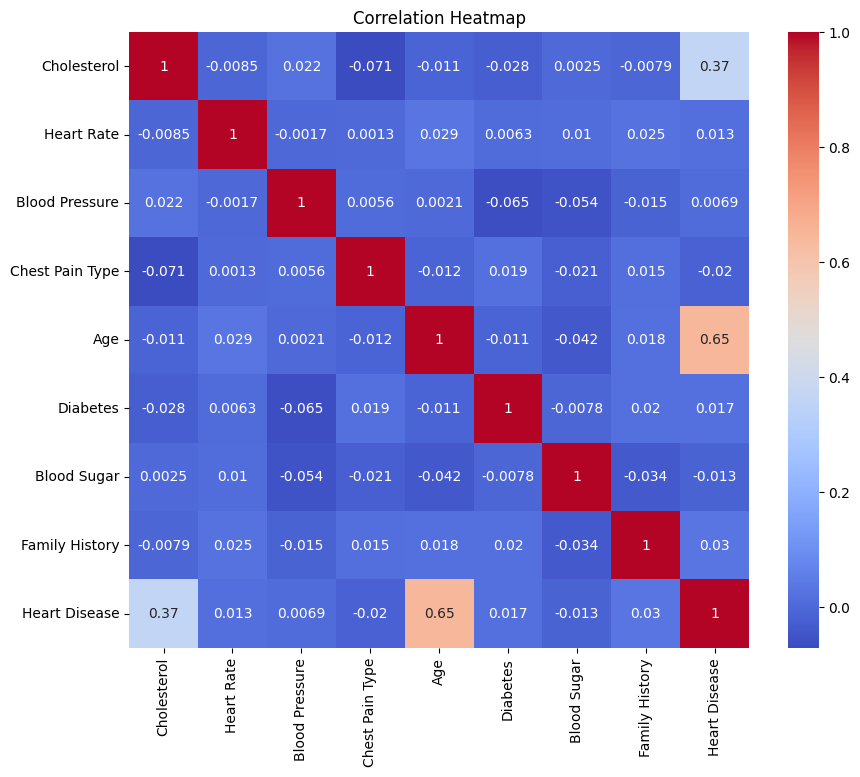

In [108]:
# 4. After preprocessing, we can now analyze the correlations between key health features and heart disease. We will select relevant features and compute the correlation matrix, then visualize it using a heatmap.
features = ['Cholesterol', 'Heart Rate', 'Blood Pressure', 'Chest Pain Type', 'Age', 'Diabetes', 'Blood Sugar', 'Family History', 'Heart Disease']
data = df[features].copy()
corr = data.corr()

# Create a heatmap to visualize correlations between key health features and heart disease 
# Annotations (annot=True) show the correlation coefficient values
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

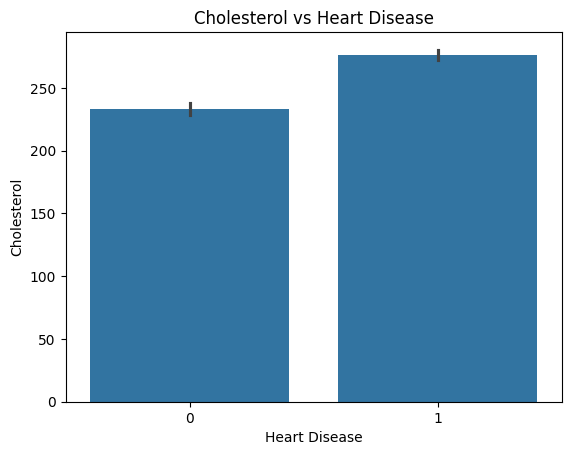

In [109]:
# 5. Visualize mean cholesterol levels based on Heart Disease presence
# x-axis: Heart Disease (typically 0=No, 1=Yes)
# y-axis: Cholesterol levels

sns.barplot(x='Heart Disease', y='Cholesterol', data=data)
plt.title("Cholesterol vs Heart Disease")
plt.show()

In [110]:
# 6. Define the feature set (independent variables) to predict heart disease and the target variable (dependent variable) which is 'Heart Disease'.
features = ['Cholesterol', 'Heart Rate', 'Family History', 'Age', 'Diabetes']
target = 'Heart Disease'

# Create feature matrix (X) and target vector (y) for machine learning models. X contains the selected features, while y contains the target variable we want to predict.
X = df[features]
y = df[target]

# Split data into training (80%) and testing (20%) sets
# random_state=42 ensures reproducibility of the split by providing a fixed set for the random number generator.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [111]:
# 7. Scaling
# Initialize the scaler object
scaler = StandardScaler()

# Fit to training data to learn mean/std, then transform it
X_train = scaler.fit_transform(X_train)

# Transform test data using the parameters learned ONLY from X_train to prevent data leakage. 
# This ensures that the test set is scaled in the same way as the training set without using any information from the test set during fitting.
X_test = scaler.transform(X_test)


Logistic Regression Accuracy: 0.885

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       118
           1       0.85      0.88      0.86        82

    accuracy                           0.89       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.89      0.89      0.89       200



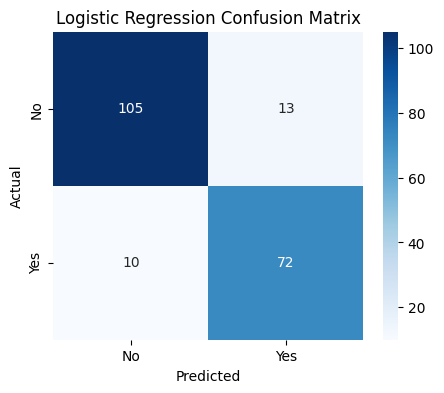

In [112]:
# 8. Models

# Logistic Regression

# Initialize Logistic Regression with balanced class weights to handle imbalanced data
# 'max_iter=1000' ensures the model converges, how long the solver runs before stopping.
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train the model on training data
logreg.fit(X_train, y_train)

# Predict on test set
y_pred_lr = logreg.predict(X_test)

# Evaluate Accuracy of Logistic Regression model by comparing predicted labels (y_pred_lr) with true labels (y_test) using accuracy_score, 
# which calculates the proportion of correct predictions.
lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

# Detailed Classification Report (Precision, Recall, F1-Score) 
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix Calculation
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_lr)

# Generate and visualize the Confusion Matrix to see True vs False positives/negatives
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

KNN Accuracy: 0.94

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       118
           1       0.92      0.94      0.93        82

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



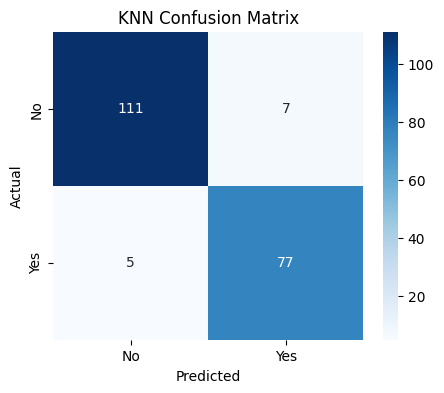

In [113]:
# KNN Model

# Set the number of nearest neighbors (hyperparameter tuning) 
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

# Fit the KNN model using the training data 
knn.fit(X_train, y_train)

# Generate predictions on the unseen test dataset 
y_pred_knn = knn.predict(X_test)

# Calculate and display the overall classification accuracy 
knn_acc = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_acc)

# Detailed Classification Report (Precision, Recall, F1-Score) 
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

# Confusion Matrix Calculation
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

# Generate and visualize the Confusion Matrix to see True vs False positives/negatives
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

Random Forest Accuracy: 1.0

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        82

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



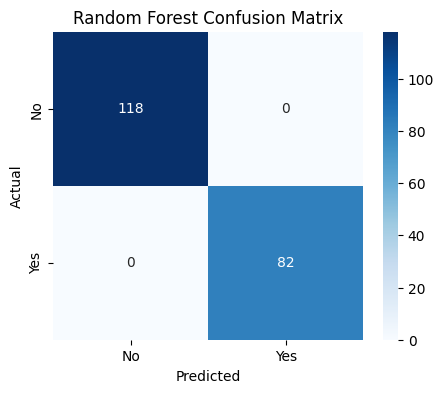

In [114]:
# Random Forest

# Initialize Random Forest with 300 trees and a fixed set for reproducibility 
rf = RandomForestClassifier(n_estimators=300, random_state=42)

# Train the model using the training data
rf.fit(X_train, y_train)

# Generate predictions on the unseen test dataset 
y_pred_rf = rf.predict(X_test)

# Calculate and display the overall classification accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

# Detailed Classification Report (Precision, Recall, F1-Score) 
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix Calculation
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Generate and visualize the Confusion Matrix to see True vs False positives/negatives
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [115]:
# 9. Set up the K-Fold cross-validation strategy.
# - n_splits=5: Data is split into 5 subsets (folds). The model trains on 4 and tests on 1, repeating 5 times.
# - shuffle=True: The data is shuffled before splitting, ensuring no bias from original data ordering.
# - random_state=42: Ensures reproducibility. Using the same integer ensures the same splits every time the code runs.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate Logistic Regression (logreg)
# - scoring='recall': Measures the ability of the model to find all positive samples (True Positives / (True Positives + False Negatives)).
lr_scores = cross_val_score(logreg, X, y, cv=kf, scoring='recall')
print("Logistic Regression CV Recall:", lr_scores.mean())

# Evaluate K-Nearest Neighbors (knn)
knn_scores = cross_val_score(knn, X, y, cv=kf, scoring='recall')
print("KNN CV Recall:", knn_scores.mean())

# Evaluate Random Forest (rf)
rf_scores = cross_val_score(rf, X, y, cv=kf, scoring='recall')
print("Random Forest CV Recall:", rf_scores.mean())

Logistic Regression CV Recall: 0.8742345371136462
KNN CV Recall: 0.9438168070882812
Random Forest CV Recall: 0.9953021978021978


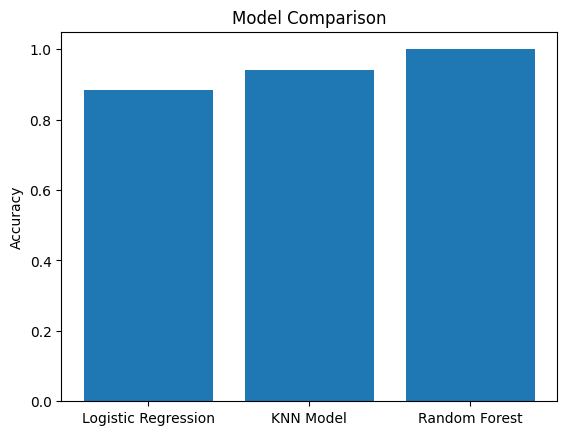

In [116]:
# 10. Model Comparison

# Define models and their corresponding accuracy scores
models = ['Logistic Regression', 'KNN Model', 'Random Forest']
accuracies = [lr_acc, knn_acc, rf_acc]

# Create the bar plot to visually compare the accuracy of the three models. Each bar represents a model, and its height corresponds to the accuracy score.
plt.figure()
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()


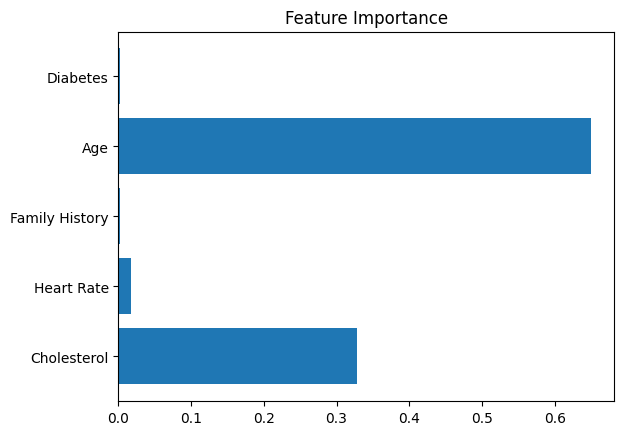

In [117]:
# 11. Feature Importance

# Extract impurity-based feature importances from the fitted Random Forest model
# Higher values indicate more important features for predicting heart disease.
importances = rf.feature_importances_

plt.figure()

# Create a horizontal bar chart mapping feature names to their importance scores
# Use X.columns to provide the labels for the y-axis. 
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()